In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/train.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(550068, 12)
['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category', 'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category_1', 'Product_Category_2', 'Product_Category_3', 'Purchase']


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [3]:
print(df.shape)
df.info()

(550068, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [4]:
print(df['User_ID'].nunique())
print(df['Product_ID'].nunique())

5891
3631


In [5]:
print(df['Gender'].value_counts())
print("---")
print(df['Age'].value_counts())
print("---")
print(df['City_Category'].value_counts())
print("---")
print(df['Stay_In_Current_City_Years'].value_counts())
print("---")
print(df['Marital_Status'].value_counts())

Gender
M    414259
F    135809
Name: count, dtype: int64
---
Age
26-35    219587
36-45    110013
18-25     99660
46-50     45701
51-55     38501
55+       21504
0-17      15102
Name: count, dtype: int64
---
City_Category
B    231173
C    171175
A    147720
Name: count, dtype: int64
---
Stay_In_Current_City_Years
1     193821
2     101838
3      95285
4+     84726
0      74398
Name: count, dtype: int64
---
Marital_Status
0    324731
1    225337
Name: count, dtype: int64


In [6]:
df.groupby('User_ID')['Gender'].nunique().value_counts()

Gender
1    5891
Name: count, dtype: int64

In [6]:
print(df['Purchase'].describe())

count    550068.000000
mean       9263.968713
std        5023.065394
min          12.000000
25%        5823.000000
50%        8047.000000
75%       12054.000000
max       23961.000000
Name: Purchase, dtype: float64


In [7]:
customer_df = df.groupby('User_ID').agg(
    Total_Purchase=('Purchase', 'sum'),
    Avg_Purchase=('Purchase', 'mean'),
    Num_Transactions=('Purchase', 'count'),
    Gender=('Gender', 'first'),
    Age=('Age', 'first'),
    Occupation=('Occupation', 'first'),
    City_Category=('City_Category', 'first'),
    Stay_In_Current_City_Years=('Stay_In_Current_City_Years', 'first'),
    Marital_Status=('Marital_Status', 'first')
).reset_index()

print(customer_df.shape)
customer_df.head()

(5891, 10)


,User_ID,Total_Purchase,Avg_Purchase,Num_Transactions,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status
0,1000001,334093,9545.514286,35,F,0-17,10,A,2,0
1,1000002,810472,10525.610390,77,M,55+,16,C,4+,0
2,1000003,341635,11780.517241,29,M,26-35,15,A,3,0
3,1000004,206468,14747.714286,14,M,46-50,7,B,2,1
4,1000005,821001,7745.292453,106,M,26-35,20,A,1,1


In [8]:
print(customer_df.shape)

(5891, 10)


In [9]:
customer_df[['Total_Purchase', 'Avg_Purchase', 'Num_Transactions']].describe()

,Total_Purchase,Avg_Purchase,Num_Transactions
count,5.891000e+03,5891.000000,5891.000000
mean,8.650166e+05,9568.839914,93.374300
std,9.436445e+05,1890.087105,107.190049
min,4.668100e+04,2318.733333,6.000000
25%,2.376780e+05,8287.212366,26.000000
50%,5.212130e+05,9386.208333,54.000000
75%,1.119250e+06,10654.633199,117.000000
max,1.053691e+07,18577.893617,1026.000000


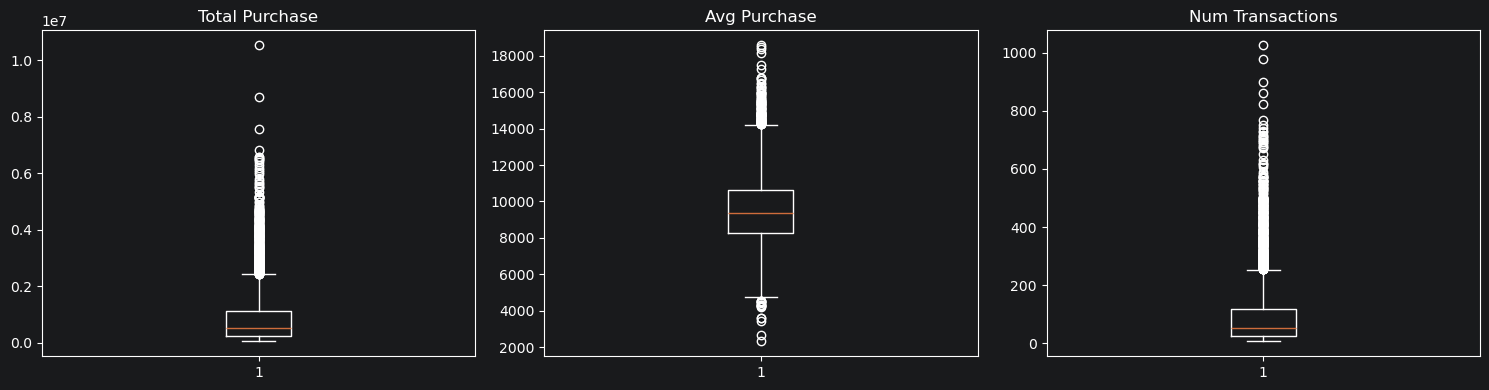

In [10]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.boxplot(customer_df['Total_Purchase'])
plt.title('Total Purchase')

plt.subplot(1, 3, 2)
plt.boxplot(customer_df['Avg_Purchase'])
plt.title('Avg Purchase')

plt.subplot(1, 3, 3)
plt.boxplot(customer_df['Num_Transactions'])
plt.title('Num Transactions')

plt.tight_layout()
plt.show()

In [11]:
print(customer_df['Gender'].value_counts())
print("---")
print(customer_df['Age'].value_counts())
print("---")
print(customer_df['City_Category'].value_counts())
print("---")
print(customer_df['Stay_In_Current_City_Years'].value_counts())
print("---")
print(customer_df['Marital_Status'].value_counts())

Gender
M    4225
F    1666
Name: count, dtype: int64
---
Age
26-35    2053
36-45    1167
18-25    1069
46-50     531
51-55     481
55+       372
0-17      218
Name: count, dtype: int64
---
City_Category
C    3139
B    1707
A    1045
Name: count, dtype: int64
---
Stay_In_Current_City_Years
1     2086
2     1145
3      979
4+     909
0      772
Name: count, dtype: int64
---
Marital_Status
0    3417
1    2474
Name: count, dtype: int64


In [12]:
print(customer_df['Age'].nunique())
print(customer_df['City_Category'].nunique())
print(customer_df['Stay_In_Current_City_Years'].nunique())
print(customer_df['Occupation'].nunique())

7
3
5
21


In [13]:
customer_df.groupby('Occupation')['Total_Purchase'].mean().sort_values(ascending=False)

Occupation
20    1.086339e+06
19    1.038037e+06
5     1.023872e+06
16    1.014242e+06
3     9.529539e+05
2     9.297992e+05
0     9.235566e+05
18    9.062905e+05
4     9.003304e+05
14    8.824990e+05
8     8.669052e+05
15    8.497158e+05
11    8.339970e+05
7     8.331414e+05
6     8.263894e+05
1     8.213040e+05
12    8.123655e+05
17    8.009806e+05
9     6.175005e+05
10    6.033566e+05
13    5.137106e+05
Name: Total_Purchase, dtype: float64

In [14]:
print(customer_df.groupby('Occupation')['Total_Purchase'].mean().sort_values(ascending=False))

Occupation
20    1.086339e+06
19    1.038037e+06
5     1.023872e+06
16    1.014242e+06
3     9.529539e+05
2     9.297992e+05
0     9.235566e+05
18    9.062905e+05
4     9.003304e+05
14    8.824990e+05
8     8.669052e+05
15    8.497158e+05
11    8.339970e+05
7     8.331414e+05
6     8.263894e+05
1     8.213040e+05
12    8.123655e+05
17    8.009806e+05
9     6.175005e+05
10    6.033566e+05
13    5.137106e+05
Name: Total_Purchase, dtype: float64


In [15]:
from scipy.stats import f_oneway

groups = [customer_df[customer_df['Occupation'] == occ]['Total_Purchase'] for occ in customer_df['Occupation'].unique()]
f_stat, p_value = f_oneway(*groups)
print(f"Occupation: p-value = {p_value:.10f}")

Occupation: p-value = 0.0000000048


In [16]:
occupation_encoding = customer_df.groupby('Occupation')['Total_Purchase'].mean()
customer_df['Occupation_encoded'] = customer_df['Occupation'].map(occupation_encoding)

print(customer_df[['Occupation', 'Occupation_encoded']].head(10))

   Occupation  Occupation_encoded
0          10        6.033566e+05
1          16        1.014242e+06
2          15        8.497158e+05
3           7        8.331414e+05
4          20        1.086339e+06
5           9        6.175005e+05
6           1        8.213040e+05
7          12        8.123655e+05
8          17        8.009806e+05
9           1        8.213040e+05


In [17]:
age_order = {'0-17': 0, '18-25': 1, '26-35': 2, '36-45': 3, '46-50': 4, '51-55': 5, '55+': 6}
customer_df['Age_encoded'] = customer_df['Age'].map(age_order)

print(customer_df[['Age', 'Age_encoded']].drop_duplicates().sort_values('Age_encoded'))

      Age  Age_encoded
0    0-17            0
17  18-25            1
2   26-35            2
6   36-45            3
3   46-50            4
5   51-55            5
1     55+            6


In [18]:
customer_df['Gender_encoded'] = customer_df['Gender'].map({'M': 1, 'F': 0})

customer_df = pd.get_dummies(customer_df, columns=['City_Category', 'Stay_In_Current_City_Years'])

bool_cols = [col for col in customer_df.columns if customer_df[col].dtype == 'bool']
customer_df[bool_cols] = customer_df[bool_cols].astype(int)

print(customer_df.shape)
print(customer_df.columns.tolist())

(5891, 19)
['User_ID', 'Total_Purchase', 'Avg_Purchase', 'Num_Transactions', 'Gender', 'Age', 'Occupation', 'Marital_Status', 'Occupation_encoded', 'Age_encoded', 'Gender_encoded', 'City_Category_A', 'City_Category_B', 'City_Category_C', 'Stay_In_Current_City_Years_0', 'Stay_In_Current_City_Years_1', 'Stay_In_Current_City_Years_2', 'Stay_In_Current_City_Years_3', 'Stay_In_Current_City_Years_4+']


In [19]:
cluster_features = customer_df[[
    'Total_Purchase', 'Avg_Purchase', 'Num_Transactions',
    'Occupation_encoded', 'Age_encoded', 'Gender_encoded', 'Marital_Status',
    'City_Category_A', 'City_Category_B', 'City_Category_C',
    'Stay_In_Current_City_Years_0', 'Stay_In_Current_City_Years_1',
    'Stay_In_Current_City_Years_2', 'Stay_In_Current_City_Years_3', 'Stay_In_Current_City_Years_4+'
]]

print(cluster_features.shape)
cluster_features.head()

(5891, 15)


,Total_Purchase,Avg_Purchase,Num_Transactions,Occupation_encoded,Age_encoded,Gender_encoded,Marital_Status,City_Category_A,City_Category_B,City_Category_C,Stay_In_Current_City_Years_0,Stay_In_Current_City_Years_1,Stay_In_Current_City_Years_2,Stay_In_Current_City_Years_3,Stay_In_Current_City_Years_4+
0,334093,9545.514286,35,6.033566e+05,0,0,0,1,0,0,0,0,1,0,0
1,810472,10525.610390,77,1.014242e+06,6,1,0,0,0,1,0,0,0,0,1
2,341635,11780.517241,29,8.497158e+05,2,1,0,1,0,0,0,0,0,1,0
3,206468,14747.714286,14,8.331414e+05,4,1,1,0,1,0,0,0,1,0,0
4,821001,7745.292453,106,1.086339e+06,2,1,1,1,0,0,0,1,0,0,0


In [20]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled_features = scaler.fit_transform(cluster_features)

scaled_df = pd.DataFrame(scaled_features, columns=cluster_features.columns)
print(scaled_df.describe())

       Total_Purchase  Avg_Purchase  Num_Transactions  Occupation_encoded  \
count     5891.000000   5891.000000       5891.000000         5891.000000   
mean         0.389989      0.077144          0.432685            0.149637   
std          1.070412      0.798374          1.177913            1.069492   
min         -0.538280     -2.985306         -0.527473           -3.286029   
25%         -0.321625     -0.464217         -0.307692           -0.277859   
50%          0.000000      0.000000          0.000000            0.000000   
75%          0.678375      0.535783          0.692308            0.722141   
max         11.361184      3.882573         10.681319            2.314099   

       Age_encoded  Gender_encoded  Marital_Status  City_Category_A  \
count  5891.000000     5891.000000     5891.000000      5891.000000   
mean      0.620438       -0.282804        0.419963         0.177389   
std       1.499592        0.450400        0.493594         0.382030   
min      -2.000000    

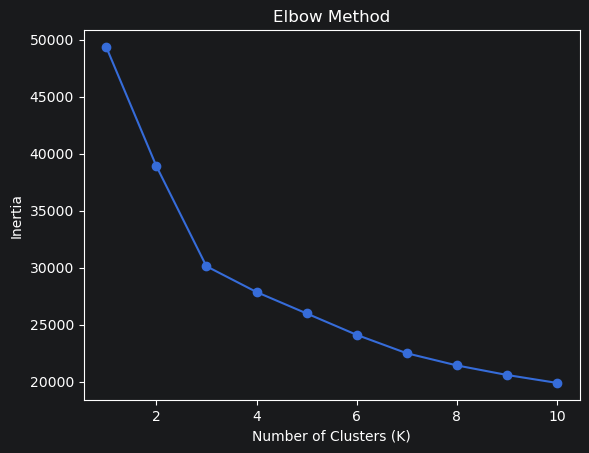

In [21]:
Sfrom sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

K=2: silhouette score = 0.2972
K=3: silhouette score = 0.2669
K=4: silhouette score = 0.2065
K=5: silhouette score = 0.1453
K=6: silhouette score = 0.1598
K=7: silhouette score = 0.1614
K=8: silhouette score = 0.1474
K=9: silhouette score = 0.1505
K=10: silhouette score = 0.1428


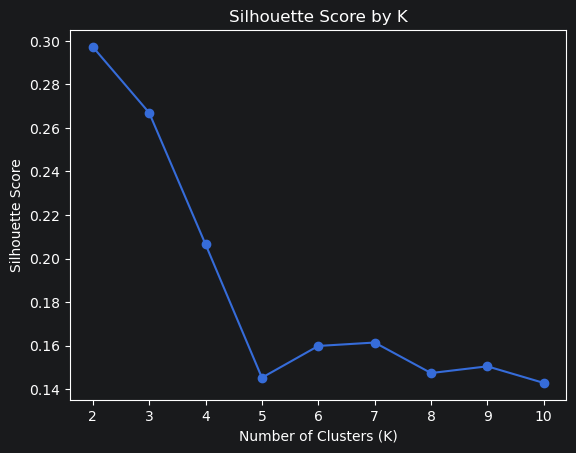

In [22]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range_sil = range(2, 11)

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    silhouette_scores.append(score)
    print(f"K={k}: silhouette score = {score:.4f}")

plt.plot(k_range_sil, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')
plt.show()

In [23]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_df['Cluster'] = kmeans_final.fit_predict(scaled_df)

print(customer_df['Cluster'].value_counts())

Cluster
2    3800
1    1289
0     802
Name: count, dtype: int64


In [24]:
cluster_summary = customer_df.groupby('Cluster')[
    ['Total_Purchase', 'Avg_Purchase', 'Num_Transactions', 'Occupation_encoded', 'Age_encoded', 'Gender_encoded', 'Marital_Status']
].mean()

print(cluster_summary)

         Total_Purchase  Avg_Purchase  Num_Transactions  Occupation_encoded  \
Cluster                                                                       
0          2.766864e+06   9004.498112        312.197007       899432.758563   
1          5.396942e+05   9575.116465         56.740884       837227.534693   
2          5.739795e+05   9685.816664         59.617632       867179.309846   

         Age_encoded  Gender_encoded  Marital_Status  
Cluster                                               
0           2.291771        0.775561        0.377805  
1           4.916214        0.688906        0.691234  
2           1.911053        0.714474        0.336842  


In [25]:
print(customer_df.groupby('Cluster')['Gender'].value_counts(normalize=True).unstack())
print("---")
print(customer_df.groupby('Cluster')['City_Category'].value_counts(normalize=True).unstack())

Gender          F         M
Cluster                    
0        0.224439  0.775561
1        0.311094  0.688906
2        0.285526  0.714474
---


KeyError: 'Column not found: City_Category'

In [26]:
print(customer_df.groupby('Cluster')[['City_Category_A', 'City_Category_B', 'City_Category_C']].mean())

         City_Category_A  City_Category_B  City_Category_C
Cluster                                                   
0               0.347880         0.628429         0.023691
1               0.114042         0.205586         0.680372
2               0.162895         0.246842         0.590263


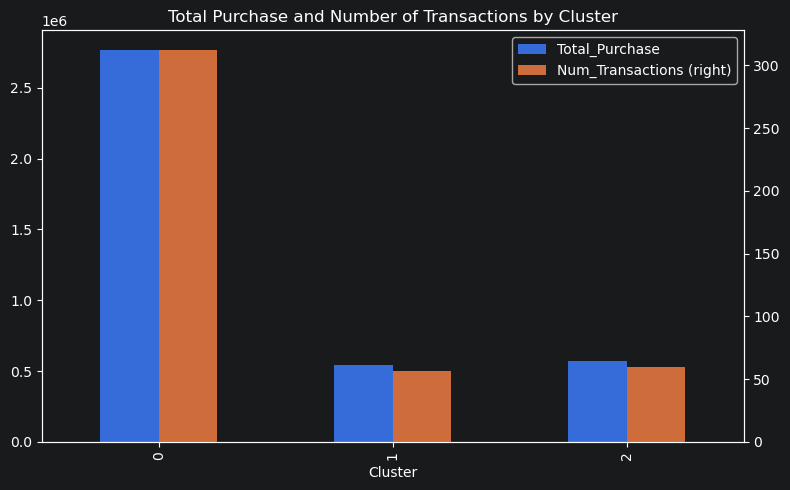

In [27]:
cluster_summary[['Total_Purchase', 'Num_Transactions']].plot(kind='bar', figsize=(8, 5), secondary_y='Num_Transactions')
plt.title('Total Purchase and Number of Transactions by Cluster')
plt.tight_layout()
plt.show()